# DIAMOND PRICE PREDICTION

In [2]:
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings 

warnings.filterwarnings("ignore")

In [3]:
df = pd.read_csv("D:\\machine learning\\supervised_learning\\regression\\diamond_price_project\\diamond_price_dataset.csv")
df

,carat,cut,color,clarity,depth,table,x,y,z,price
0,0.23,Ideal,E,SI2,61.5,55.0,3.95,3.98,2.43,326
1,0.21,Premium,E,SI1,59.8,61.0,3.89,3.84,2.31,326
2,0.23,Good,E,VS1,56.9,65.0,4.05,4.07,2.31,327
3,0.29,Premium,I,VS2,62.4,58.0,4.20,4.23,2.63,334
4,0.31,Good,J,SI2,63.3,58.0,4.34,4.35,2.75,335
...,...,...,...,...,...,...,...,...,...,...
53938,0.86,Premium,H,SI2,61.0,58.0,6.15,6.12,3.74,2757
53939,0.75,Ideal,D,SI2,62.2,55.0,5.83,5.87,3.64,2757
53940,0.71,Premium,E,SI1,60.5,55.0,5.79,5.74,3.49,2756
53941,0.71,Premium,F,SI1,59.8,62.0,5.74,5.73,3.43,2756


# EDA

In [4]:
df.shape

(53943, 10)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53943 entries, 0 to 53942
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53943 non-null  float64
 1   cut      53943 non-null  object 
 2   color    53943 non-null  object 
 3   clarity  53943 non-null  object 
 4   depth    53943 non-null  float64
 5   table    53943 non-null  float64
 6   x        53943 non-null  float64
 7   y        53943 non-null  float64
 8   z        53943 non-null  float64
 9   price    53943 non-null  int64  
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


In [6]:
df.describe()

,carat,depth,table,x,y,z,price
count,53943.000000,53943.000000,53943.000000,53943.000000,53943.000000,53943.000000,53943.000000
mean,0.797935,61.749322,57.457251,5.731158,5.734526,3.538730,3932.734294
std,0.473999,1.432626,2.234549,1.121730,1.142103,0.705679,3989.338447
min,0.200000,43.000000,43.000000,0.000000,0.000000,0.000000,326.000000
25%,0.400000,61.000000,56.000000,4.710000,4.720000,2.910000,950.000000
50%,0.700000,61.800000,57.000000,5.700000,5.710000,3.530000,2401.000000
75%,1.040000,62.500000,59.000000,6.540000,6.540000,4.040000,5324.000000
max,5.010000,79.000000,95.000000,10.740000,58.900000,31.800000,18823.000000


In [7]:
df.drop_duplicates(inplace=True)
df.shape

(53794, 10)

In [8]:
# target variable exploration 

<Axes: xlabel='price', ylabel='Count'>

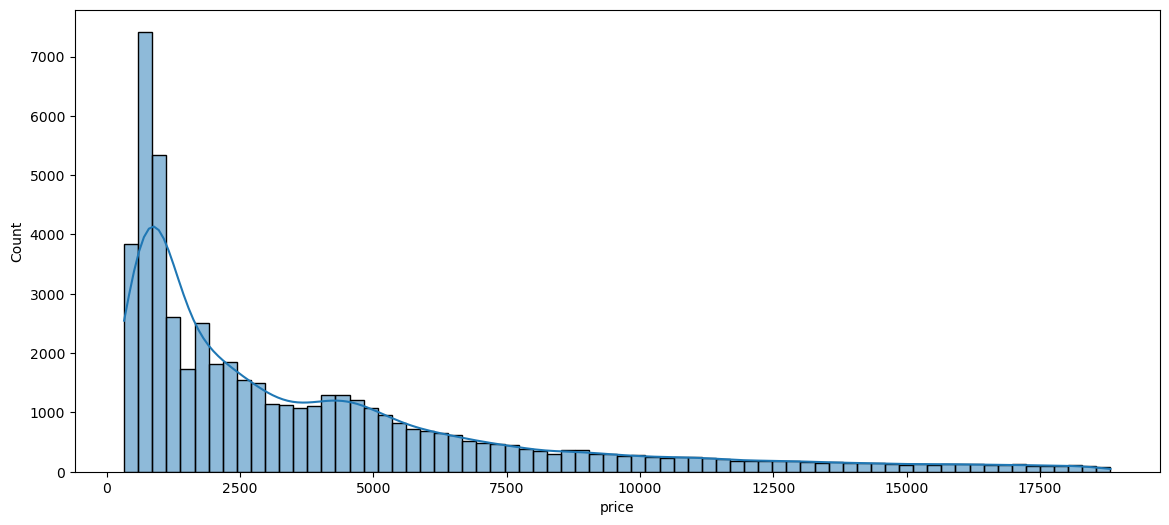

In [9]:
plt.figure(figsize=(14,6))
sns.histplot(df['price'], kde=True, bins=70)

<Axes: xlabel='price'>

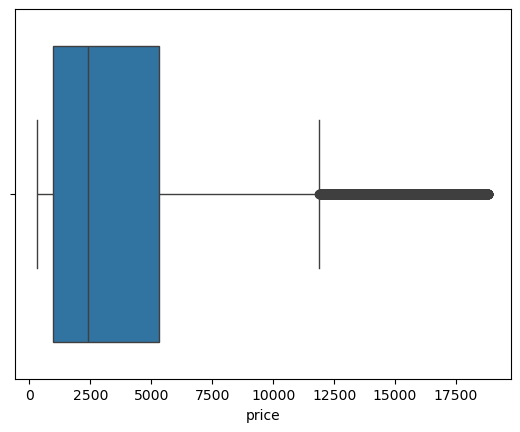

In [10]:
sns.boxplot(x=df['price'])

In [11]:
# categorical features ana;ysis

<Axes: xlabel='cut', ylabel='count'>

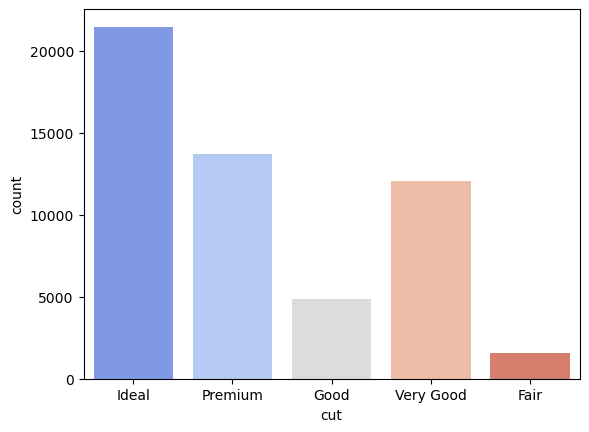

In [12]:
sns.countplot(x=df['cut'], palette='coolwarm')

<Axes: xlabel='color', ylabel='count'>

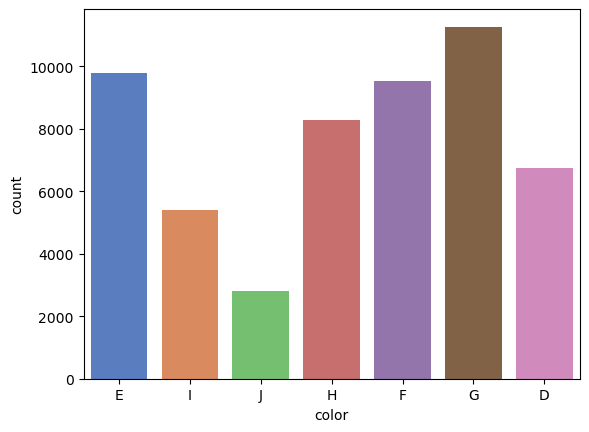

In [13]:
sns.countplot(x=df['color'], palette='muted')

<Axes: xlabel='clarity', ylabel='count'>

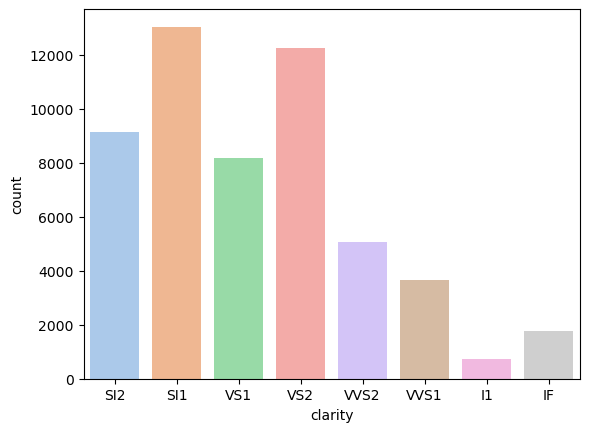

In [14]:
sns.countplot(x=df['clarity'], palette='pastel')

In [15]:
df.head()

,carat,cut,color,clarity,depth,table,x,y,z,price
0,0.23,Ideal,E,SI2,61.5,55.0,3.95,3.98,2.43,326
1,0.21,Premium,E,SI1,59.8,61.0,3.89,3.84,2.31,326
2,0.23,Good,E,VS1,56.9,65.0,4.05,4.07,2.31,327
3,0.29,Premium,I,VS2,62.4,58.0,4.20,4.23,2.63,334
4,0.31,Good,J,SI2,63.3,58.0,4.34,4.35,2.75,335


In [16]:
# numerical features analysis

<Axes: xlabel='carat', ylabel='Count'>

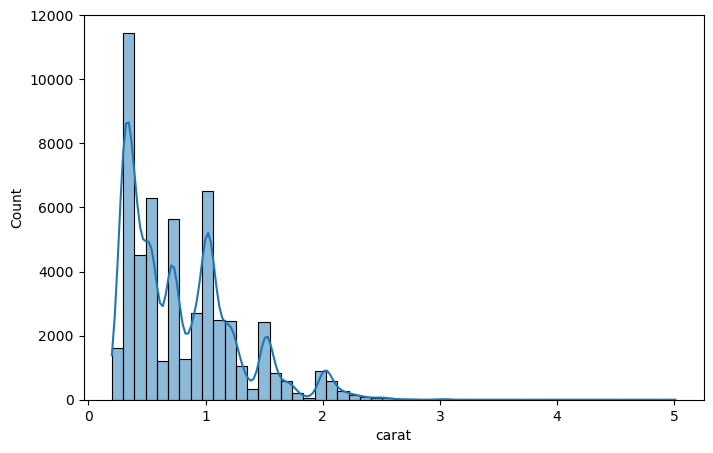

In [17]:
plt.figure(figsize=(8,5))
sns.histplot(df['carat'], kde=True, bins=50)

<Axes: xlabel='depth', ylabel='Count'>

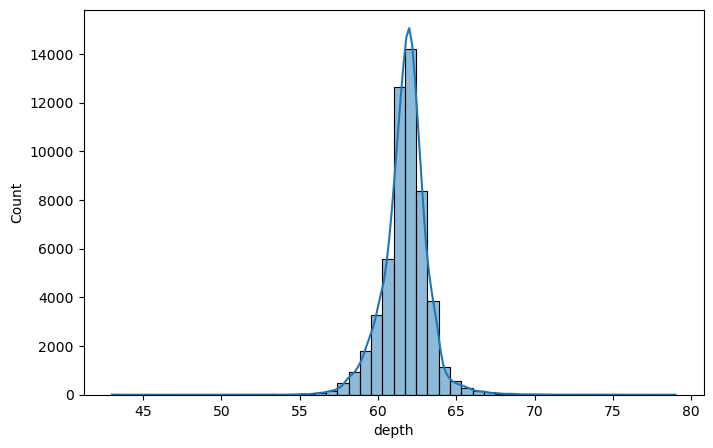

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(df['depth'], kde=True, bins=50)

<Axes: xlabel='table', ylabel='Count'>

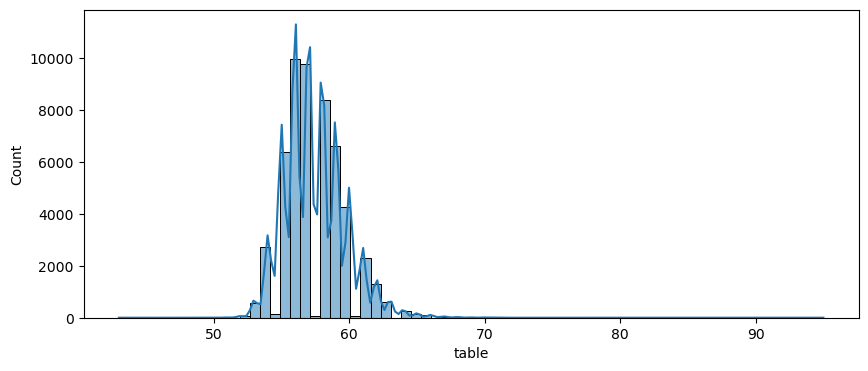

In [19]:
plt.figure(figsize=(10,4))
sns.histplot(df['table'], kde=True, bins=70)

<Axes: xlabel='x', ylabel='Count'>

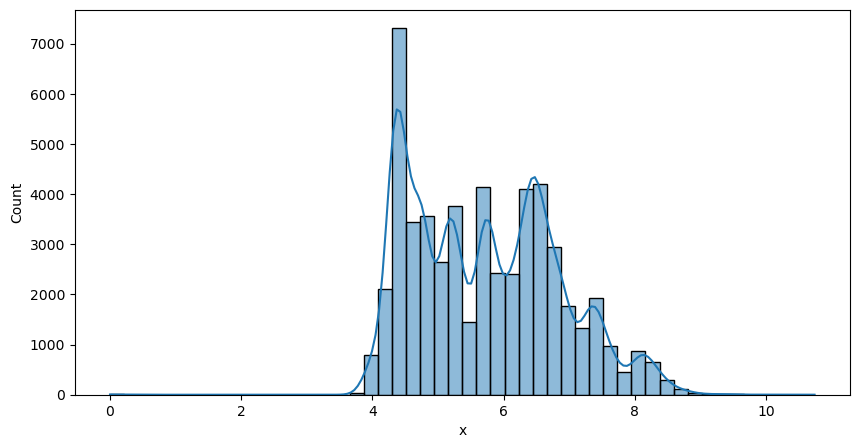

In [20]:
plt.figure(figsize=(10,5))
sns.histplot(df['x'], kde=True, bins=50)

<Axes: xlabel='y', ylabel='Count'>

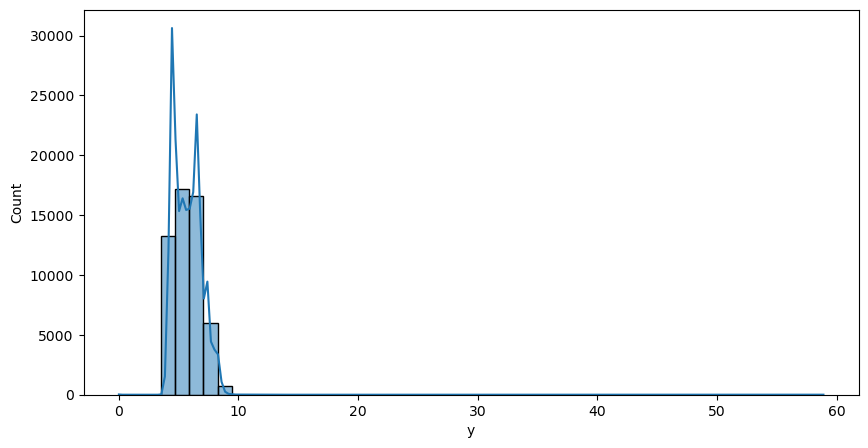

In [21]:
plt.figure(figsize=(10,5))
sns.histplot(df['y'], kde=True, bins=50)

<Axes: xlabel='z', ylabel='Count'>

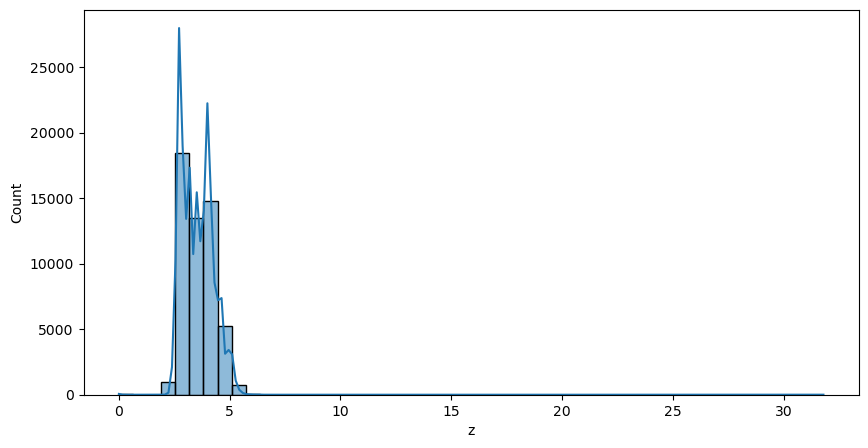

In [22]:
plt.figure(figsize=(10,5))
sns.histplot(df['z'], kde=True, bins=50)

In [23]:
# heatmap

<Axes: >

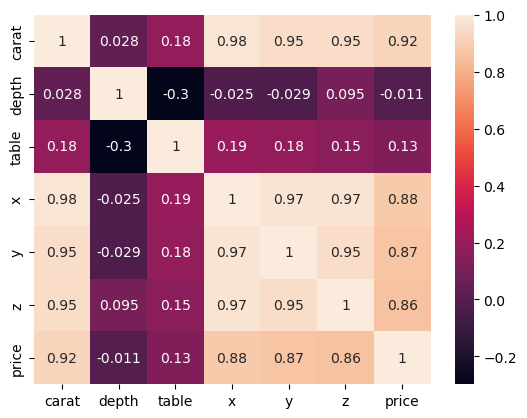

In [24]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [25]:
# creating X & y

In [26]:
X = df.drop(columns='price', axis=1)
y = df['price']

# DATA PREPROCESSING

In [27]:
# encoding

X = pd.get_dummies(X, drop_first=True, dtype=int)
X.head()

,carat,depth,table,x,y,z,cut_Good,cut_Ideal,cut_Premium,cut_Very Good,...,color_H,color_I,color_J,clarity_IF,clarity_SI1,clarity_SI2,clarity_VS1,clarity_VS2,clarity_VVS1,clarity_VVS2
0,0.23,61.5,55.0,3.95,3.98,2.43,0,1,0,0,...,0,0,0,0,0,1,0,0,0,0
1,0.21,59.8,61.0,3.89,3.84,2.31,0,0,1,0,...,0,0,0,0,1,0,0,0,0,0
2,0.23,56.9,65.0,4.05,4.07,2.31,1,0,0,0,...,0,0,0,0,0,0,1,0,0,0
3,0.29,62.4,58.0,4.20,4.23,2.63,0,0,1,0,...,0,1,0,0,0,0,0,1,0,0
4,0.31,63.3,58.0,4.34,4.35,2.75,1,0,0,0,...,0,0,1,0,0,1,0,0,0,0


- splitting data

In [28]:
from sklearn.model_selection import train_test_split

In [29]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [30]:
# scaling

In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [32]:
X_test.columns

Index(['carat', 'depth', 'table', 'x', 'y', 'z', 'cut_Good', 'cut_Ideal',
       'cut_Premium', 'cut_Very Good', 'color_E', 'color_F', 'color_G',
       'color_H', 'color_I', 'color_J', 'clarity_IF', 'clarity_SI1',
       'clarity_SI2', 'clarity_VS1', 'clarity_VS2', 'clarity_VVS1',
       'clarity_VVS2'],
      dtype='object')

# Regression Base Models

In [31]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import AdaBoostRegressor
from sklearn.ensemble import GradientBoostingRegressor
from xgboost import XGBRegressor

In [32]:
s_models = {
    'LR': LinearRegression(),
    'KNN': KNeighborsRegressor(),
    'SVR': SVR()
}

us_models = {
    'DT': DecisionTreeRegressor(),
    'RF': RandomForestRegressor(),
    'GDB': GradientBoostingRegressor(),
    'ADB': AdaBoostRegressor(),
    'XGB': XGBRegressor()
}

results = []

In [ ]:
for name, model in s_models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    results.append({
        'name': name,
        'r2': round(r2,4),
        'mae': round(mae,4),
        'rmse': round(rmse,4),
        'mse': round(mse,2)
    })

for name, model in us_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    results.append({
        'name': name,
        'r2': round(r2,4),
        'mae': round(mae,4),
        'rmse': round(rmse,4),
        'mse': round(mse,2)
    })

In [ ]:
results_df = pd.DataFrame(results)
results_df

,name,r2,mae,rmse,mse
0,LR,0.9203,725.2703,1102.3130,1215093.90
1,KNN,0.9541,417.7887,836.5901,699882.93
2,SVR,0.3445,1672.8626,3160.9571,9991649.68
3,DT,0.9532,379.8044,844.4903,713163.85
4,RF,0.9774,283.7568,587.2506,344863.26
5,GDB,0.9546,437.7653,831.8131,691913.09
6,ADB,0.8566,944.2542,1478.2334,2185173.93
7,XGB,0.9797,289.0156,555.9659,309098.06


- XGB score : r2 = 97.97 ; mae = 289.0 ; rmse = 555.9
- XGB (XG Boost Regressor) is best model 
- so now hypertuning XGB

In [ ]:
xgb_model = us_models['XGB']
xgb_model

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


# Hypertuning - XGB

In [ ]:
from sklearn.model_selection import RandomizedSearchCV

In [ ]:
random = RandomizedSearchCV(estimator=xgb_model, param_distributions={
    'max_depth': [2, 3, 5, 6, 10, 15],
    'n_estimators': [50, 100, 200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
    'booster': ['gbtree', 'dart'],
    'subsample': [0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    'gamma': [0, 0.1, 0.2, 0.5, 1.0] 
}, n_iter=10, cv=5, return_train_score=False, n_jobs=-1, random_state=42, scoring='r2')

In [ ]:
random.fit(X_train, y_train) 

,estimator,"XGBRegressor(...ree=None, ...)"
,param_distributions,"{'booster': ['gbtree', 'dart'], 'gamma': [0, 0.1, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [2, 3, ...], ...}"
,n_iter,10
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [ ]:
results = pd.DataFrame(random.cv_results_)
results[['param_max_depth', 'param_n_estimators', 'param_learning_rate', 'param_booster', 'param_subsample', 'mean_test_score']].sort_values(by='mean_test_score', ascending=False)

,param_max_depth,param_n_estimators,param_learning_rate,param_booster,param_subsample,mean_test_score
8,15,500,0.01,dart,0.9,0.976944
7,6,200,0.30,gbtree,0.9,0.976825
6,6,200,0.10,gbtree,0.9,0.976778
3,15,50,0.20,dart,0.6,0.974162
1,10,300,0.30,gbtree,0.7,0.973604
5,10,500,0.30,dart,0.6,0.972609
2,15,300,0.30,dart,0.7,0.972441
4,15,50,0.05,dart,0.9,0.967545
9,3,200,0.05,dart,0.5,0.953046
0,5,100,0.01,dart,0.9,0.797768


In [ ]:
random.best_score_

np.float64(0.9769439578056336)

In [ ]:
best_model = random.best_estimator_
best_model

,objective,'reg:squarederror'
,base_score,None
,booster,'dart'
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [ ]:
# checking test score

In [ ]:
y_pred = best_model.predict(X_test)

In [ ]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("r2 = ",r2, "\nmae = ",mae, "\nmse = ",mse, "\nrmse = ", rmse)

r2 =  0.9803946018218994 
mae =  272.2734375 
mse =  298826.53125 
rmse =  546.6502824018296


- so XGB after hypertuning is better model

In [ ]:
final_model = random.best_estimator_
final_model

,objective,'reg:squarederror'
,base_score,None
,booster,'dart'
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [ ]:
# saving the model

In [ ]:
import joblib

In [ ]:
joblib.dump(final_model, "model.pkl")
joblib.dump(X_test.columns.tolist(), "columns.pkl")

['columns.pkl']